# Parameters

In [3]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.utils.parameters import (
    mcwf_dt_from_scales,
    omega_c,
    scaled_N_Gamma,
)
from common.utils.phases import default_three_phase_protocol
from parser.moments import MomentSeries, SimulationMetadata

%reload_ext autoreload
%autoreload 2

output_dir = repo_root / "output"

### Parameters

NJi = 5
Omega0 = 1.0
delta0 = 0.2
NJi = 20
Omega0 = 4.0
delta0 = 0.8
NJi = 80
Omega0 = 16.0
delta0 = 3.2
NJi = 250
Omega0 = 50.0
delta0 = 10.0


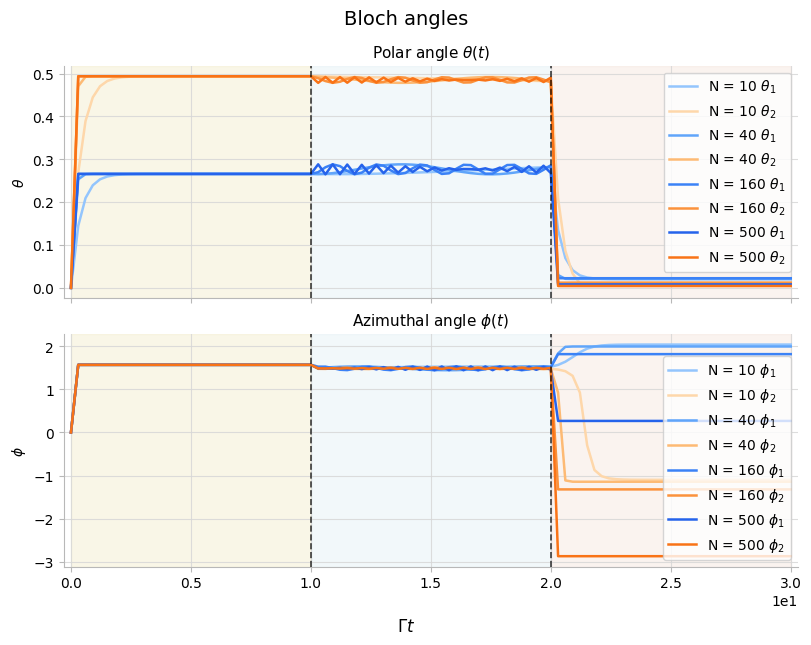

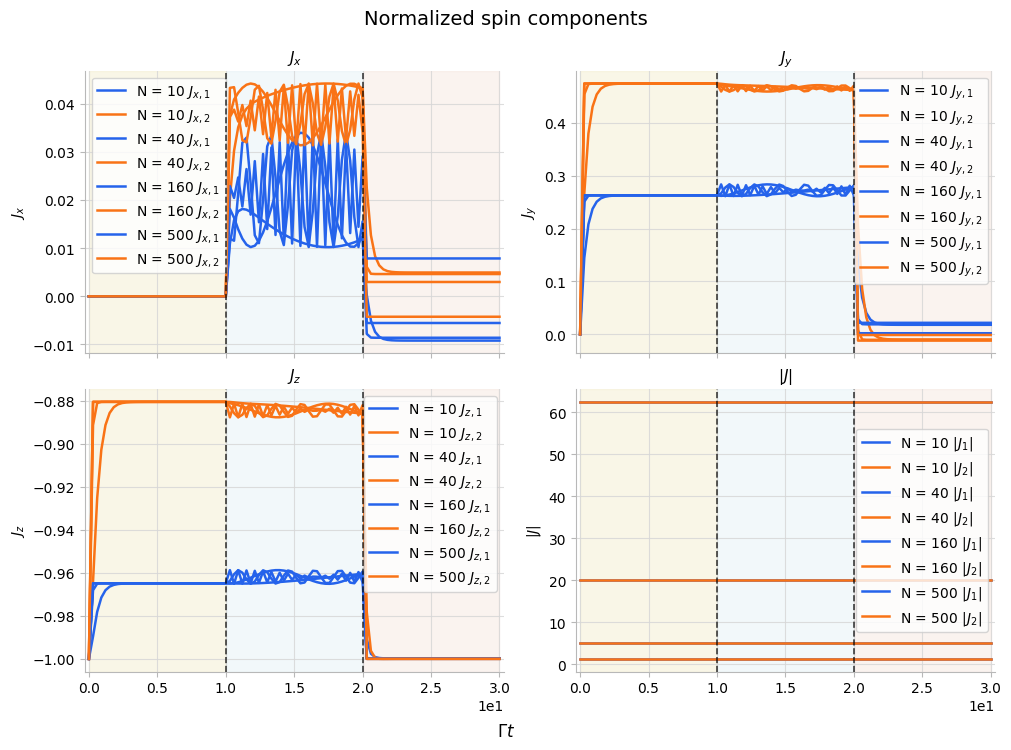

In [ ]:
from solvers.mfe import compute_mfe_j_moments, solve_mfe
from parser.mfe import MFESolverParameters

from common.plotting import (
    plot_bloch_angles,
    plot_spin_components,
)

# common fixed
Gamma = 1; num_snapshots=100
# param
dN = 0


Omega_factor = 0.1
delta_factor = 0.02
omega_i = [0.7]

# protocol durations
T1 = 10.0
T2 = 10.0
T3 = 10.0

axes_angles = None
axes_spins = None
for i, NJi in enumerate((5,20,80,250)):
    Ni = [NJi,NJi]
    # Model and parameters
    Omega0 = scaled_N_Gamma(Omega_factor, sum(Ni), Gamma)
    delta0 = scaled_N_Gamma(delta_factor, sum(Ni), Gamma)

    phase_protocol = default_three_phase_protocol(
        durations=(T1, T2, T3),
        delta0=delta0,
        Omega0=Omega0,
    )
    simulation_metadata = SimulationMetadata(
        Ni=tuple(Ni),
        omega_i=tuple(omega_i),
        Gamma=Gamma,
        phase_protocol=phase_protocol,
    )

    print(f"NJi = {NJi}")
    print(f"Omega0 = {Omega0}")
    print(f"delta0 = {delta0}")

    # moment initialization
    mfe_moments = MomentSeries(
        num_snapshots=num_snapshots,
        metadata=simulation_metadata,
    )

    # Define method parameters and solve using mean-field equations
    mfe_parameters = MFESolverParameters(
        Ni=simulation_metadata.Ni,
        omega_i=simulation_metadata.omega_groups,
        Gamma=simulation_metadata.Gamma,
        phase_protocol=simulation_metadata.phase_protocol,
    )
    mfe_result = solve_mfe(
        mfe_parameters,
        t_eval=mfe_moments.t,
    )

    # compute moments
    mfe_moments.J = compute_mfe_j_moments(mfe_result)

    fig, axes_angles = plot_bloch_angles(
        mfe_moments.J,
        phase_protocol=mfe_moments.metadata.phase_protocol,
        label=f"N = {2*NJi}",
        #colour_family_index=0,
        shade_index=i,
        linestyle="-",
        axes=axes_angles,
        output_path=f"{output_dir}/mfe_parameter_scaling/angles.png",
    )

    fig, axes_spins = plot_spin_components(
        mfe_moments.J,
        normalized=True,
        phase_protocol=mfe_moments.metadata.phase_protocol,
        label=f"N = {2*NJi}",
        colour_family_index=i,
        linestyle="-",
        axes=axes_spins,
        output_path=f"{output_dir}/mfe_parameter_scaling/spins.png",
        
    )
    


### Mean-field Equations